In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
purchase_price = pd.read_csv("2017PurchasePricesDec.csv")
beg_inv = pd.read_csv("BegInvFINAL12312016.csv")
end_inv = pd.read_csv("EndInvFINAL12312016.csv")
invoice = pd.read_csv("InvoicePurchases12312016.csv")
final_purchase = pd.read_csv("PurchasesFINAL12312016.csv")
final_sales = pd.read_csv("SalesFINAL12312016.csv")

In [3]:
# Check nulls
print(purchase_price.isnull().sum())
print(end_inv.isnull().sum())

# Drop nulls
purchase_price.dropna(inplace=True)
end_inv.dropna(inplace=True)

Brand             0
Description       1
Price             0
Size              1
Volume            1
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
dtype: int64
InventoryId       0
Store             0
City           1284
Brand             0
Description       0
Size              0
onHand            0
Price             0
endDate           0
dtype: int64


In [4]:
print(purchase_price.head())
print(beg_inv.head())
print(final_sales.head())

print(purchase_price.describe())

   Brand                  Description  Price   Size Volume  Classification  \
0     58  Gekkeikan Black & Gold Sake  12.99  750mL    750               1   
1     62     Herradura Silver Tequila  36.99  750mL    750               1   
2     63   Herradura Reposado Tequila  38.99  750mL    750               1   
3     72         No. 3 London Dry Gin  34.99  750mL    750               1   
4     75    Three Olives Tomato Vodka  14.99  750mL    750               1   

   PurchasePrice  VendorNumber                   VendorName  
0           9.28          8320  SHAW ROSS INT L IMP LTD      
1          28.67          1128  BROWN-FORMAN CORP            
2          30.46          1128  BROWN-FORMAN CORP            
3          26.11          9165  ULTRA BEVERAGE COMPANY LLP   
4          10.94          7245  PROXIMO SPIRITS INC.         
         InventoryId  Store          City  Brand                  Description  \
0  1_HARDERSFIELD_58      1  HARDERSFIELD     58  Gekkeikan Black & Gold Sake 

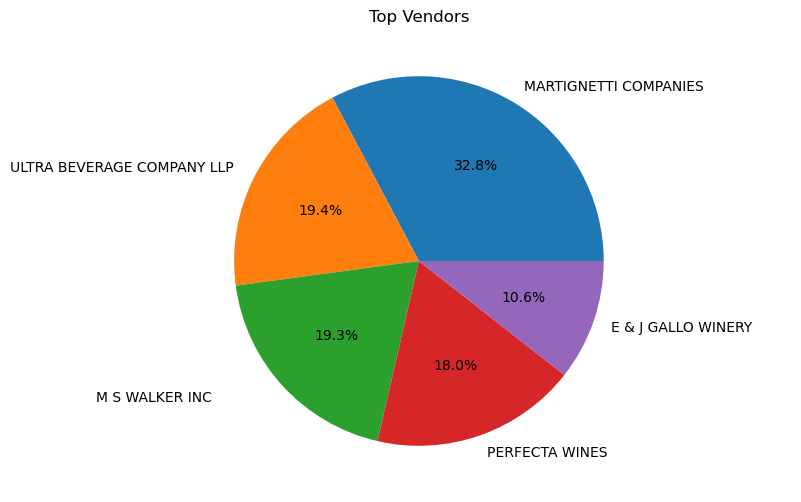

In [5]:
top_vendors = purchase_price['VendorName'].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(top_vendors, labels=top_vendors.index, autopct='%1.1f%%')
plt.title("Top Vendors")
plt.show()

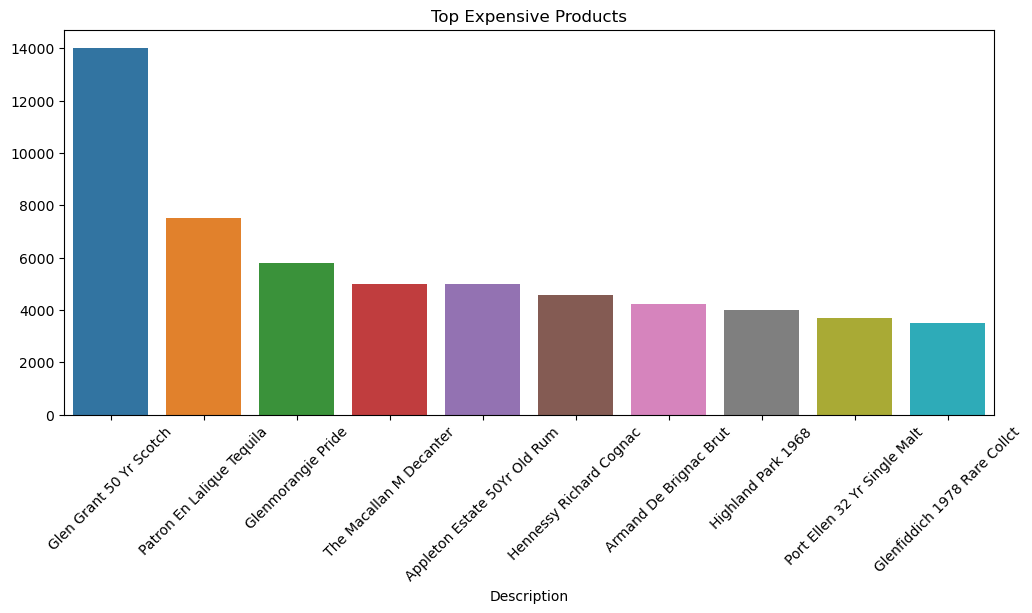

In [6]:
top_products = purchase_price.groupby('Description')['Price'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_products.index, y=top_products.values)
plt.xticks(rotation=45)
plt.title("Top Expensive Products")
plt.show()

In [7]:
total_sales = final_sales['SalesDollars'].sum()
avg_inventory = (beg_inv['onHand'].mean() + end_inv['onHand'].mean()) / 2

inventory_turnover = total_sales / avg_inventory
print("Inventory Turnover:", inventory_turnover)

Inventory Turnover: 1566183.2863264736


In [8]:
avg_daily_sales = final_sales['SalesQuantity'].mean()
lead_time = 7  # assume 7 days

reorder_point = avg_daily_sales * lead_time
print("Reorder Point:", reorder_point)

Reorder Point: 16.363334048589753


In [9]:
D = final_sales['SalesQuantity'].sum()   # demand
S = 50   # ordering cost (assumed)
H = 5    # holding cost (assumed)

EOQ = np.sqrt((2 * D * S) / H)
print("EOQ:", EOQ)

EOQ: 7001.669800840368


In [10]:
holding_cost_rate = 0.2
inventory_value = (beg_inv['onHand'] * beg_inv['Price']).sum()

carrying_cost = holding_cost_rate * inventory_value
print("Carrying Cost:", carrying_cost)

Carrying Cost: 13610756.034000002


In [11]:
# Create total sales value per product
abc = final_sales.groupby('Description').agg({
    'SalesDollars': 'sum'
}).reset_index()

# Sort descending
abc = abc.sort_values(by='SalesDollars', ascending=False)

# Percentage contribution
abc['Percentage'] = (abc['SalesDollars'] / abc['SalesDollars'].sum()) * 100

# Cumulative %
abc['Cumulative %'] = abc['Percentage'].cumsum()

In [12]:
def classify(x):
    if x <= 70:
        return 'A'
    elif x <= 90:
        return 'B'
    else:
        return 'C'

abc['Category'] = abc['Cumulative %'].apply(classify)

abc.head()

,Description,SalesDollars,Percentage,Cumulative %,Category
1137,Capt Morgan Spiced Rum,610008.34,1.840736,1.840736,A
3348,Jack Daniels No 7 Black,558064.03,1.683991,3.524727,A
73,Absolut 80 Proof,422095.29,1.273697,4.798424,A
6378,Tito's Handmade Vodka,420186.25,1.267937,6.066360,A
3650,Ketel One Vodka,417950.59,1.261190,7.327551,A


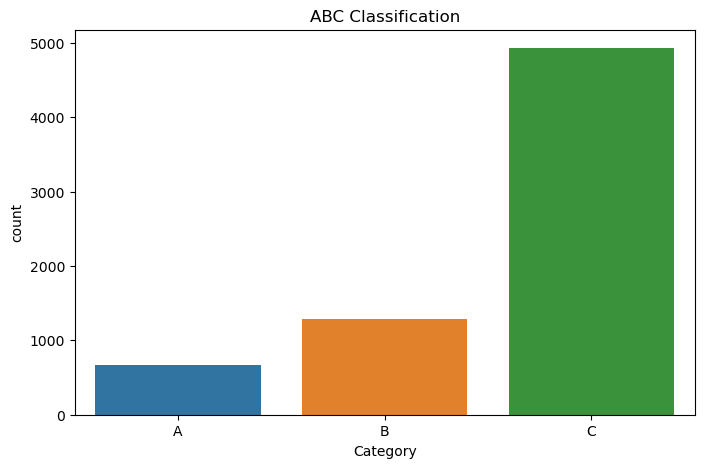

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Category', data=abc)
plt.title("ABC Classification")
plt.show()

In [14]:
# Convert date
final_sales['SalesDate'] = pd.to_datetime(final_sales['SalesDate'])

# Extract time features
final_sales['Day'] = final_sales['SalesDate'].dt.day
final_sales['Month'] = final_sales['SalesDate'].dt.month
final_sales['Year'] = final_sales['SalesDate'].dt.year

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = final_sales[['Day', 'Month', 'Year']]
y = final_sales['SalesQuantity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 12.458074834602732
